In [ ]:
import pandas as pd
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind

In [6]:
# Load data
df = pd.read_csv("pima_indians_diabetes.csv")

In [7]:
df.shape

(767, 9)

## Linear Regression

##### Data Pima Indians Diabetes tidak cocok untuk Linear Regression biasa kalau target (y) adalah Outcome karena:
##### Karena Outcome adalah variabel kategorikal biner (0 = tidak diabetes, 1 = diabetes)
##### Linear Regression = untuk prediksi angka kontinu, Prediksi bisa lebih dari 1 atau kurang dari 0
##### Linear Regression akan memaksa model mencari garis lurus terbaik untuk mendekati nilai target.
##### Linear regression pakai Mean Squared Error, padahal untuk klasifikasi lebih cocok Log Loss (seberapa jauh prediksi probabilitas model dari label asli)

## KNN Manual


Nilai k terbaik: 7 dengan akurasi: 77.27%

Contoh prediksi pertama:
Data ke-1: Prediksi = 0, Asli = 0, ✓
Data ke-2: Prediksi = 1, Asli = 1, ✓
Data ke-3: Prediksi = 0, Asli = 1, ✗
Data ke-4: Prediksi = 0, Asli = 0, ✓
Data ke-5: Prediksi = 0, Asli = 0, ✓
Data ke-6: Prediksi = 0, Asli = 1, ✗
Data ke-7: Prediksi = 1, Asli = 1, ✓
Data ke-8: Prediksi = 0, Asli = 0, ✓
Data ke-9: Prediksi = 0, Asli = 0, ✓
Data ke-10: Prediksi = 0, Asli = 0, ✓

Akurasi KNN Manual (k terbaik = 7): 77.27%
Jumlah prediksi BENAR  : 119
Jumlah prediksi SALAH  : 35


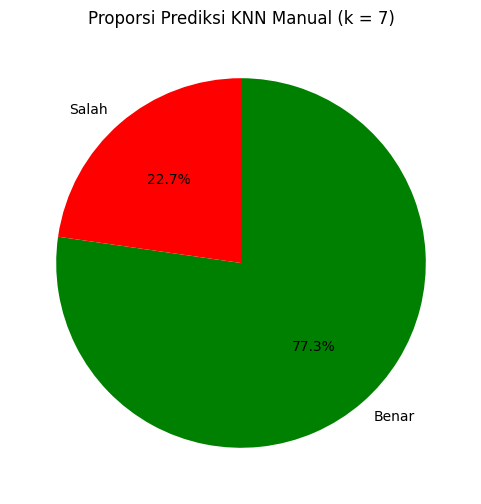


--- Uji 1 Titik ---
distance: [(0.10518206970330188, 0), (0.11845533300740589, 0), (0.142691633619798, 0), (0.1445131067845966, 0), (0.1545037163194537, 0), (0.15658205276590675, 0), (0.1586281974549098, 0)], k: 7
The value classified to unknown point is: 0
Label asli: 0


In [60]:
# Normalisasi fitur manual (semua kecuali Outcome)
#agar semua fitur berada pada rentang 0–1, karena KNN sangat sensitif terhadap skala data.
for col in df.columns[:-1]:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col] = (df[col] - min_val) / (max_val - min_val)

# Shuffle dan Split Data
# 80% data latih (train_data) dan 20% data uji (test_data)
data = df.values.tolist()
random_state = 42
random.seed(random_state)
random.shuffle(data)
split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

# Memisahkan data latih berdasarkan kelas target (Outcome)
# 0 (tidak diabetes) dan 1 (diabetes)
points = {0: [], 1: []}
for row in train_data:
    label = int(row[-1]) 
    features = tuple(row[:-1])
    points[label].append(features)

# Hitung jarak Euclidean
def euclidean_distance(a, b):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

# Menghitung jarak titik p terhadap semua data latih.
# Mengambil k tetangga terdekat.
# Hitung mayoritas kelas dari tetangga itu.
# Return 0 atau 1 sesuai hasil mayoritas.

def classifyAPoint(points, p, k=5):
    distance = []
    for group in points:
        for feature in points[group]:
            dist = euclidean_distance(feature, p)
            distance.append((dist, group))
    distance = sorted(distance)[:k]

    freq = {0: 0, 1: 0}
    for d in distance:
        freq[d[1]] += 1

    prediction = 0 if freq[0] > freq[1] else 1
    return prediction

# Siapkan X_test dan y_test
X_test = [row[:-1] for row in test_data]
y_test = [int(row[-1]) for row in test_data]

# Cari nilai k terbaik
best_k = None
best_acc = 0
acc_list = []

#Dicoba dari k 1-20
for k_try in range(1, 21):
    y_pred = [classifyAPoint(points, tuple(row), k=k_try) for row in X_test]
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_k = k_try

print(f"\nNilai k terbaik: {best_k} dengan akurasi: {best_acc * 100:.2f}%")

# Prediksi manual dengan k terbaik untuk 10 data pertama.
y_pred_manual = []
print("\nContoh prediksi pertama:")
for i, row in enumerate(X_test[:10]):
    pred = classifyAPoint(points, tuple(row), k=best_k)
    y_pred_manual.append(pred)
    benar = "✓" if pred == y_test[i] else "✗"
    print(f"Data ke-{i+1}: Prediksi = {pred}, Asli = {y_test[i]}, {benar}")

# Tambahkan prediksi sisanya untuk akurasi penuh
y_pred_manual += [classifyAPoint(points, tuple(row), k=best_k) for row in X_test[10:]]

# Evaluasi akurasi
total_y_test = y_test
acc_manual = accuracy_score(total_y_test, y_pred_manual)
print(f"\nAkurasi KNN Manual (k terbaik = {best_k}): {acc_manual * 100:.2f}%")

# Hitung jumlah benar dan salah
jumlah_benar = sum([p == t for p, t in zip(y_pred_manual, total_y_test)])
jumlah_salah = len(total_y_test) - jumlah_benar

# Print jumlah benar dan salah
print(f"Jumlah prediksi BENAR  : {jumlah_benar}")
print(f"Jumlah prediksi SALAH  : {jumlah_salah}")

# Visualisasi prediksi benar vs salah
hasil = ["✓" if pred == true else "✗" for pred, true in zip(y_pred_manual, total_y_test)]
warna = ["green" if h == "✓" else "red" for h in hasil]

hasil_counter = Counter(hasil)
labels = ['Benar', 'Salah']
sizes = [hasil_counter['✓'], hasil_counter['✗']]
colors = ['green', 'red']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title(f"Proporsi Prediksi KNN Manual (k = {best_k})")
plt.show()

# --- Uji 1 Titik ---
sample = test_data[0]
features = tuple(sample[:-1])
true_label = int(sample[-1])

print(f"\n--- Uji 1 Titik ---")
distance = []
for group in points:
    for feature in points[group]:
        dist = euclidean_distance(feature, features)
        distance.append((dist, group))
distance = sorted(distance)[:best_k]
print(f"distance: {distance}, k: {best_k}")

freq = {0: 0, 1: 0}
for d in distance:
    freq[d[1]] += 1

prediction = 0 if freq[0] > freq[1] else 1
print(f"The value classified to unknown point is: {prediction}")
print(f"Label asli: {true_label}")

## Confusion Matrix KNN

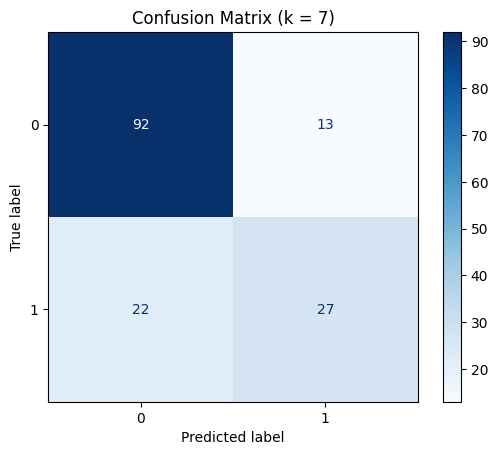

In [ ]:
# Confusion Matrix
cm = confusion_matrix(total_y_test, y_pred_manual)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (k = {best_k})")
plt.show() 

## Cari feature importance

In [ ]:
# 1. Load dataset
df = pd.read_csv("pima_indians_diabetes_with_header.csv")

# 2. Pisahkan fitur dan target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 3. Normalisasi (optional, biar hasil lebih stabil)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 4. Hitung t-score dan p-value untuk setiap fitur
t_scores = []
p_values = []

for col in X.columns:
    group0 = X_scaled[y == 0][col]
    group1 = X_scaled[y == 1][col]
    t_stat, p_val = ttest_ind(group0, group1)
    t_scores.append(t_stat)
    p_values.append(p_val)

# 5. Buat DataFrame hasil
t_df = pd.DataFrame({
    "Feature": X.columns,
    "T-Score": t_scores,
    "P-Value": p_values
}).sort_values(by="P-Value")

# Tandai fitur signifikan (p-value < 0.05)
t_df["Significant?"] = ["Yes" if p < 0.05 else "No" for p in t_df["P-Value"]]

# 6. Print hasil
print("=== Hasil T-Test Feature Importance ===")
print(t_df)

=== Hasil T-Test Feature Importance ===
                    Feature    T-Score       P-Value Significant?
1                   Glucose -14.600060  8.935432e-43          Yes
5                       BMI  -8.471840  1.229807e-16          Yes
7                       Age  -6.792688  2.209975e-11          Yes
0               Pregnancies  -6.298431  5.065127e-10          Yes
6  DiabetesPedigreeFunction  -4.885826  1.254607e-06          Yes
4                   Insulin  -3.644325  2.861865e-04          Yes
3             SkinThickness  -2.074700  3.834770e-02          Yes
2             BloodPressure  -1.804702  7.151390e-02           No


## KNN (Only Feature Importance)


Nilai k terbaik: 5 dengan akurasi: 77.92%
Akurasi KNN Manual (Top 5 Fitur T-Test, k = 5): 77.92%
Jumlah prediksi BENAR  : 120
Jumlah prediksi SALAH  : 34


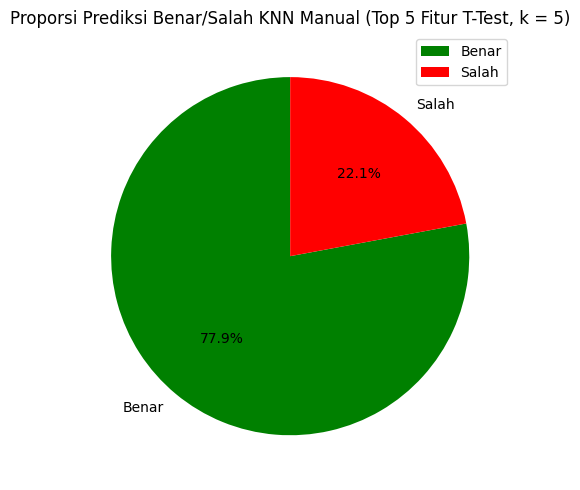

In [ ]:
# === 1. Load data ===
df = pd.read_csv("pima_indians_diabetes_with_header.csv")

# === 2. T-Test untuk semua fitur terhadap Outcome ===
features = df.columns[:-1]
t_scores = []
p_values = []

for col in features:
    group0 = df[df["Outcome"] == 0][col]
    group1 = df[df["Outcome"] == 1][col]
    t, p = ttest_ind(group0, group1)
    t_scores.append(t)
    p_values.append(p)

t_df = pd.DataFrame({
    "Feature": features,
    "T-Score": t_scores,
    "P-Value": p_values
}).sort_values(by="P-Value")

# Ambil top 5 fitur berdasarkan p-value terkecil
top_features = t_df["Feature"].head(5).tolist()

# === 3. Dataset baru hanya pakai top 5 fitur + Outcome ===
df = df[top_features + ["Outcome"]]

# === 4. Normalisasi fitur ===
for col in top_features:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# === 5. Split data ===
data = df.values.tolist()
random.seed(42)
random.shuffle(data)
split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

# === 6. Siapkan dictionary training data ===
points = {0: [], 1: []}
for row in train_data:
    label = int(row[-1])
    features = tuple(row[:-1])
    points[label].append(features)

# === 7. Euclidean Distance & KNN Manual ===
def euclidean_distance(a, b):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

def classifyAPoint(points, p, k=5):
    distance = []
    for group in points:
        for feature in points[group]:
            dist = euclidean_distance(feature, p)
            distance.append((dist, group))
    distance = sorted(distance)[:k]
    freq = {0: 0, 1: 0}
    for d in distance:
        freq[d[1]] += 1
    return 0 if freq[0] > freq[1] else 1

# === 8. Uji akurasi ===
X_test = [row[:-1] for row in test_data]
y_test = [int(row[-1]) for row in test_data]

# Cari k terbaik (1–20)
best_k = None
best_acc = 0
for k_try in range(1, 21):
    y_pred = [classifyAPoint(points, tuple(row), k=k_try) for row in X_test]
    acc = accuracy_score(y_test, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_k = k_try

print(f"\nNilai k terbaik: {best_k} dengan akurasi: {best_acc * 100:.2f}%")

# Prediksi akhir
y_pred_manual = [classifyAPoint(points, tuple(row), k=best_k) for row in X_test]
acc_manual = accuracy_score(y_test, y_pred_manual)
print(f"Akurasi KNN Manual (Top 5 Fitur T-Test, k = {best_k}): {acc_manual * 100:.2f}%")

# Hitung jumlah benar dan salah
jumlah_benar = sum([p == t for p, t in zip(y_pred_manual, y_test)])
jumlah_salah = len(y_test) - jumlah_benar

# Print jumlah benar dan salah
print(f"Jumlah prediksi BENAR  : {jumlah_benar}")
print(f"Jumlah prediksi SALAH  : {jumlah_salah}")

# === 9. Visualisasi hasil benar/salah ===
hasil = ["✓" if pred == true else "✗" for pred, true in zip(y_pred_manual, y_test)]
warna = ["green" if h == "✓" else "red" for h in hasil]

plt.figure(figsize=(12, 4))
plt.bar(range(len(y_test)), [1]*len(y_test), color=warna)
plt.title(f"Hasil Prediksi KNN Manual (Top 5 Fitur T-Test, k = {best_k})")
plt.xlabel("Index Data Test")
plt.ylabel("Benar / Salah")
legend_elements = [Patch(facecolor='green', label='Benar'), Patch(facecolor='red', label='Salah')]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

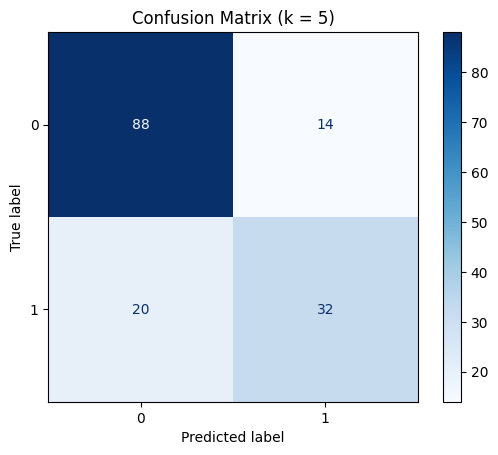

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_manual)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (k = {best_k})")
plt.show()

## Perbandingan KNN Euclidean, Manhattan, Minkowski

In [55]:
# Load data
df = pd.read_csv("pima_indians_diabetes.csv")

# Normalisasi fitur manual (kecuali Outcome)
for col in df.columns[:-1]:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col] = (df[col] - min_val) / (max_val - min_val)

# Acak & split data
data = df.values.tolist()
random.seed(42)
random.shuffle(data)
split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

# Buat dictionary points berdasarkan Outcome
points = {0: [], 1: []}
for row in train_data:
    label = int(row[-1])
    features = tuple(row[:-1])
    points[label].append(features)

# === Jarak-jarak ===
def euclidean_distance(a, b):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

def manhattan_distance(a, b):
    return sum(abs(x - y) for x, y in zip(a, b))

def minkowski_distance(a, b, p=3):
    return sum(abs(x - y) ** p for x, y in zip(a, b)) ** (1/p)

# === KNN Manual ===
def classifyAPoint(points, p, k=5, distance_func=euclidean_distance):
    distance = []
    for group in points:
        for feature in points[group]:
            dist = distance_func(feature, p)
            distance.append((dist, group))
    distance = sorted(distance)[:k]

    freq = {0: 0, 1: 0}
    for d in distance:
        freq[d[1]] += 1
    return 0 if freq[0] > freq[1] else 1

# Siapkan test set
X_test = [row[:-1] for row in test_data]
y_test = [int(row[-1]) for row in test_data]

# === Uji 3 jenis distance ===
results = {}

for name, func in {
    'Euclidean': euclidean_distance,
    'Manhattan': manhattan_distance,
    'Minkowski (p=3)': lambda a, b: minkowski_distance(a, b, p=3)
}.items():
    best_k = None
    best_acc = 0
    for k_try in range(1, 21):
        y_pred = [classifyAPoint(points, tuple(row), k=k_try, distance_func=func) for row in X_test]
        acc = accuracy_score(y_test, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_k = k_try
    results[name] = (best_k, best_acc)

# === Print hasil ===
print("\n=== Hasil Akurasi KNN Manual Berdasarkan Jarak ===")
for metric, (kval, acc) in results.items():
    print(f"{metric:<18} | k terbaik = {kval:>2} | Akurasi = {acc * 100:.2f}%")



=== Hasil Akurasi KNN Manual Berdasarkan Jarak ===
Euclidean          | k terbaik =  7 | Akurasi = 77.27%
Manhattan          | k terbaik = 20 | Akurasi = 79.22%
Minkowski (p=3)    | k terbaik = 11 | Akurasi = 78.57%


Jumlah prediksi BENAR  : 122
Jumlah prediksi SALAH  : 32


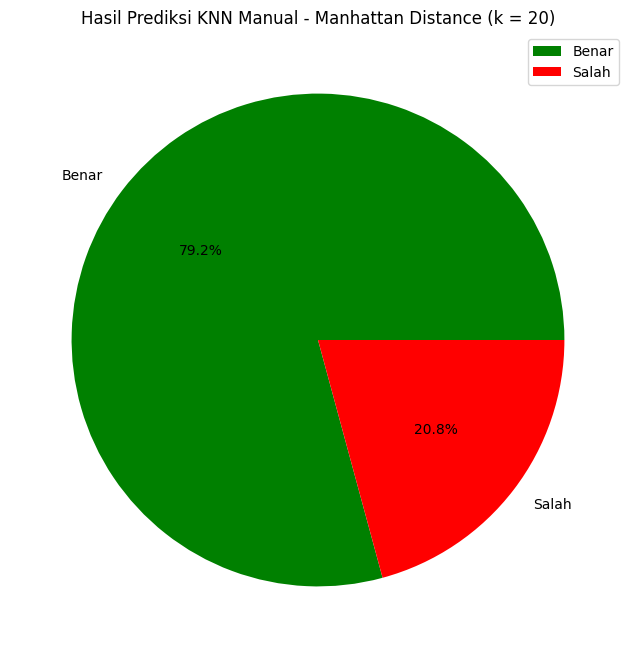

Akurasi Manhattan Distance (k = 20): 79.22%


In [57]:
# === Pakai Manhattan distance ===
def manhattan_distance(a, b):
    return sum(abs(x - y) for x, y in zip(a, b))

# === KNN manual untuk manhattan ===
def classify_manhattan(points, p, k=20):
    distance = []
    for group in points:
        for feature in points[group]:
            dist = manhattan_distance(feature, p)
            distance.append((dist, group))
    distance = sorted(distance)[:k]
    
    freq = {0: 0, 1: 0}
    for d in distance:
        freq[d[1]] += 1
    return 0 if freq[0] > freq[1] else 1

# === Prediksi dengan Manhattan ===
y_pred_manhattan = [classify_manhattan(points, tuple(row), k=20) for row in X_test]

# Hitung jumlah benar dan salah
jumlah_benar = sum([p == t for p, t in zip(y_pred_manhattan, y_test)])
jumlah_salah = len(y_test) - jumlah_benar

# Print jumlah benar dan salah
print(f"Jumlah prediksi BENAR  : {jumlah_benar}")
print(f"Jumlah prediksi SALAH  : {jumlah_salah}")
# === Visualisasi hasil benar vs salah ===
hasil = ["✓" if pred == true else "✗" for pred, true in zip(y_pred_manhattan, y_test)]
warna = ["green" if h == "✓" else "red" for h in hasil]

# Visualisasi pie chart hasil prediksi benar vs salah
plt.figure(figsize=(8, 8))
plt.pie([jumlah_benar, jumlah_salah], labels=['Benar', 'Salah'], colors=['green', 'red'], autopct='%1.1f%%')
plt.title("Hasil Prediksi KNN Manual - Manhattan Distance (k = 20)")
plt.legend()
plt.show()

#  Hitung akurasi ulang
acc = accuracy_score(y_test, y_pred_manhattan)
print(f"Akurasi Manhattan Distance (k = 20): {acc * 100:.2f}%")

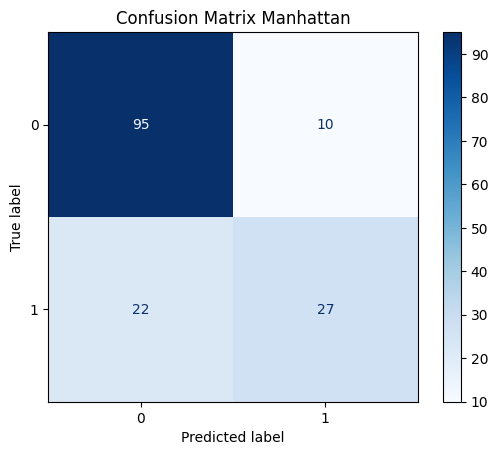

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_manhattan)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix Manhattan")
plt.show()

## Logistic Regression Manual

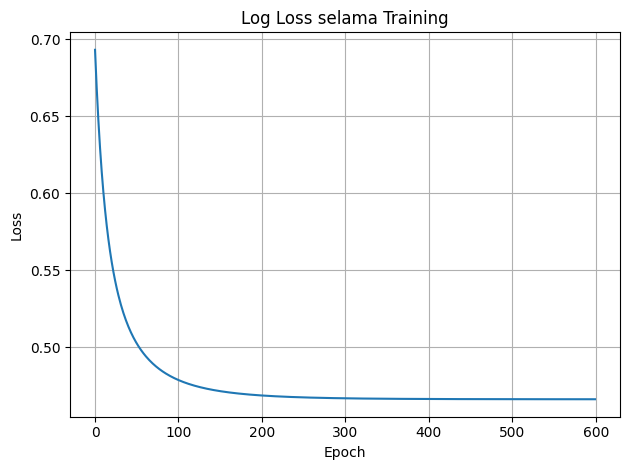


=== Evaluasi Logistic Regression Manual (Threshold Optimal = 0.28) ===
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       100
           1       0.60      0.85      0.70        54

    accuracy                           0.75       154
   macro avg       0.75      0.77      0.74       154
weighted avg       0.79      0.75      0.75       154



In [39]:
# 1. Load dataset
df = pd.read_csv("pima_indians_diabetes_with_header.csv")

# 2. Pisahkan fitur dan target
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

# 3. Standardisasi fitur
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 4. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Inisialisasi parameter
learning_rate = 0.1
n_iter = 600
b = 0
w = np.zeros(X_train.shape[1])

# 6. Definisi fungsi logistic regression
predict = lambda x, w, b: np.matmul(w, x.T) + b
sigmoid = lambda yhat: 1 / (1 + np.exp(-yhat))
loss = lambda y, sig: -(y * np.log(sig) + (1 - y) * np.log(1 - sig)).mean()
dldw = lambda x, y, sig: ((np.reshape(sig - y, (len(y), 1)) * x).mean(axis=0))
dldb = lambda y, sig: (sig - y).mean()
update = lambda a, g, lr: a - (g * lr)

# 7. Training loop
losses = []
for i in range(n_iter):
    yhat = predict(X_train, w, b)
    sig = sigmoid(yhat)
    logloss = loss(y_train, sig)
    losses.append(logloss)
    grad_w = dldw(X_train, y_train, sig)
    grad_b = dldb(y_train, sig)
    w = update(w, grad_w, learning_rate)
    b = update(b, grad_b, learning_rate)

# 8. Visualisasi loss
plt.plot(losses)
plt.title("Log Loss selama Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.grid()
plt.show()

# 9. Evaluasi di test set (cari threshold terbaik berdasarkan f1_score)
yhat_test = predict(X_test, w, b)
sig_test = sigmoid(yhat_test)

thresholds = np.arange(0.1, 0.91, 0.01)
best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (sig_test >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

# 10. Evaluasi akhir dengan threshold terbaik
ypred_test = sig_test >= best_thresh

print(f"\n=== Evaluasi Logistic Regression Manual (Threshold Optimal = {best_thresh:.2f}) ===")
print(classification_report(y_test, ypred_test))


In [40]:
# Threshold grid
thresholds = np.arange(0.0, 1.01, 0.01)
best_thresh = 0
best_f1 = 0
f1_scores = []

# Coba semua threshold
for t in thresholds:
    ypred = (sig_test >= t)
    f1 = f1_score(y_test, ypred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\n=== Threshold Terbaik ===")
print(f"Threshold = {best_thresh:.2f} menghasilkan F1-score = {best_f1:.4f}")


=== Threshold Terbaik ===
Threshold = 0.28 menghasilkan F1-score = 0.7023


Jumlah prediksi BENAR  : 114
Jumlah prediksi SALAH  : 40


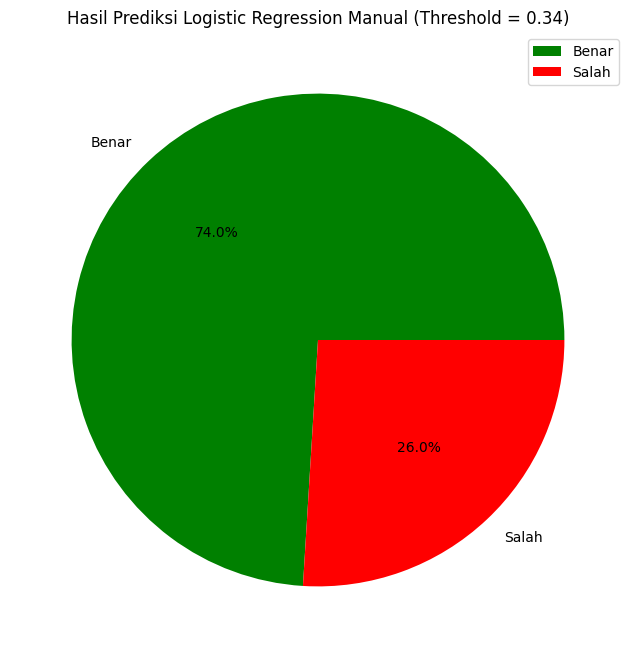

In [47]:
# Konversi ke NumPy array jika masih list
X_test = np.array(X_test)
y_test = np.array(y_test)

# Buat label prediksi biner berdasarkan threshold
ypred_test = (sigmoid(predict(X_test, w, b)) >= 0.34).astype(int)

# Hitung jumlah benar dan salah
jumlah_benar = sum(ypred_test == y_test)
jumlah_salah = len(y_test) - jumlah_benar
# Print jumlah benar dan salah
print(f"Jumlah prediksi BENAR  : {jumlah_benar}")
print(f"Jumlah prediksi SALAH  : {jumlah_salah}")

# Visualisasi pie chart
plt.figure(figsize=(8, 8))
plt.pie([jumlah_benar, jumlah_salah], labels=['Benar', 'Salah'], colors=['green', 'red'], autopct='%1.1f%%')
plt.title(f"Hasil Prediksi Logistic Regression Manual (Threshold = 0.34)")
plt.legend()
plt.show()
